Файл существует: True
Размер файла: 72960 байт
complex64: 9120 отсчётов
Пример: (-0.0001230094494530931+0j)


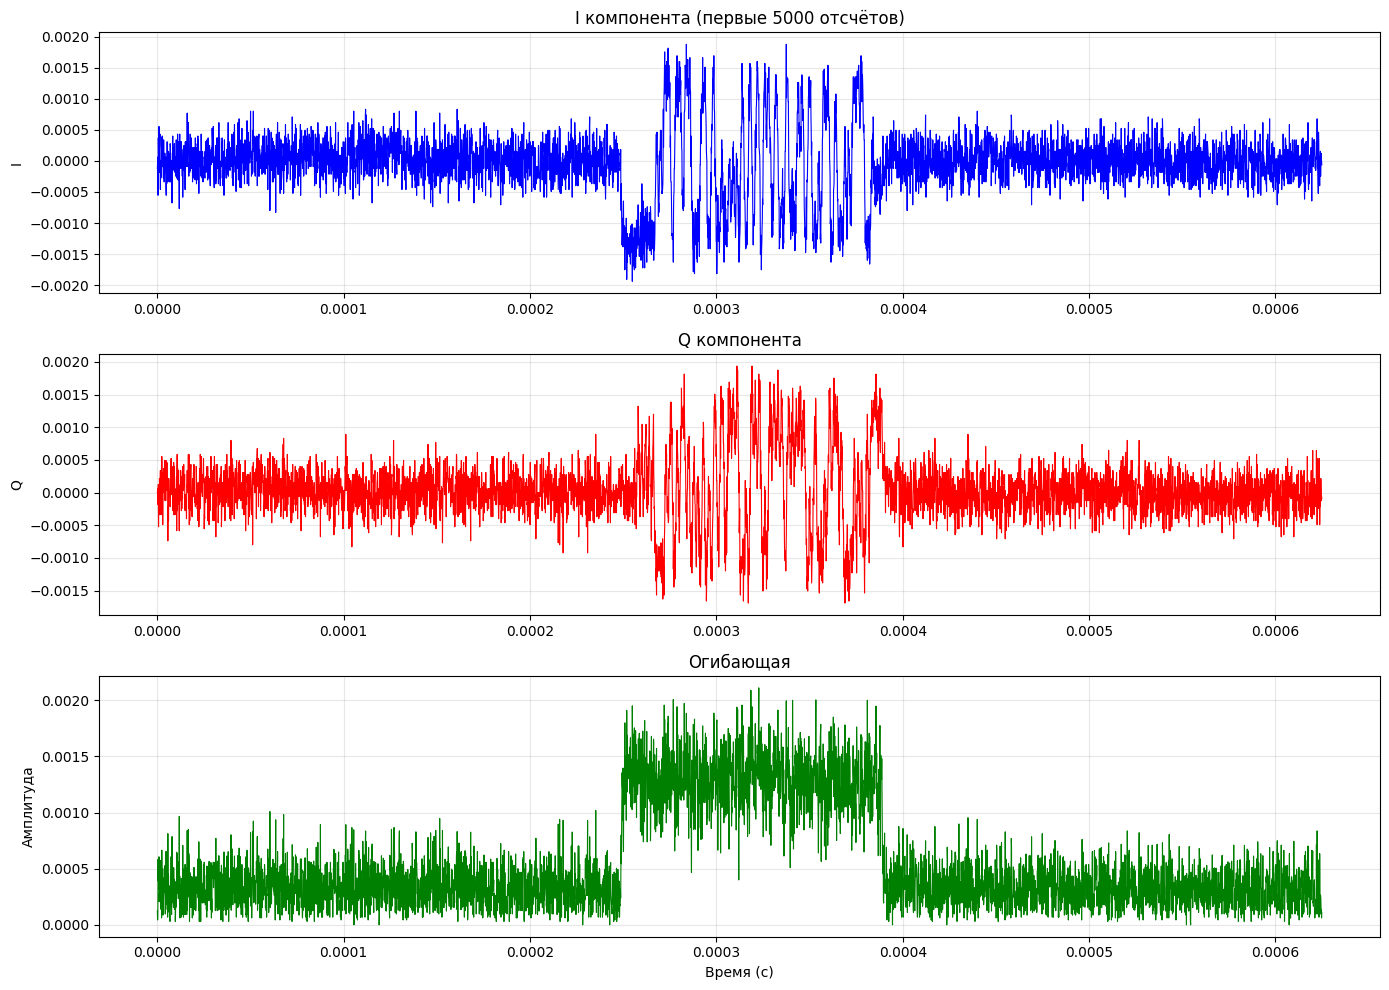

Длительность: 0.001 секунд
Всего отсчётов: 9120


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#FILE_PATH = r"C:\Users\ggwp8\Downloads\BTLE_packet_high_SNR_fs_8e6.dat"
FILE_PATH = r"C:\Users\ggwp8\Downloads\BTLE_packet_fs_8e6.dat"
FS = 8000000

def plot_signal(sig, fs=FS):
    if sig is None or len(sig) == 0:
        print("Нет данных")
        return
    
    max_samples = min(len(sig), 5000)
    t = np.arange(max_samples) / fs
    sig_show = sig[:max_samples]
    
    if np.iscomplexobj(sig):
        fig, axes = plt.subplots(3, 1, figsize=(14, 10))
        
        axes[0].plot(t, sig_show.real, 'b-', linewidth=0.8)
        axes[0].set_ylabel("I")
        axes[0].set_title(f"I компонента (первые {max_samples} отсчётов)")
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(t, sig_show.imag, 'r-', linewidth=0.8)
        axes[1].set_ylabel("Q")
        axes[1].set_title("Q компонента")
        axes[1].grid(True, alpha=0.3)
        
        axes[2].plot(t, np.abs(sig_show), 'g-', linewidth=0.8)
        axes[2].set_ylabel("Амплитуда")
        axes[2].set_xlabel("Время (с)")
        axes[2].set_title("Огибающая")
        axes[2].grid(True, alpha=0.3)
    else:
        fig, ax = plt.subplots(1, 1, figsize=(14, 4))
        ax.plot(t, sig_show, 'b-', linewidth=0.8)
        ax.set_xlabel("Время (с)")
        ax.set_ylabel("Амплитуда")
        ax.set_title("Сигнал")
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Длительность: {len(sig) / fs:.3f} секунд")
    print(f"Всего отсчётов: {len(sig)}")


path = Path(FILE_PATH)
print(f"Файл существует: {path.exists()}")
if path.exists():
    print(f"Размер файла: {path.stat().st_size} байт")
else:
    print("Файл не найден!")

if path.exists():
    file_size = path.stat().st_size
    
    # Формат complex64 (8 байт на отсчёт)
    if file_size % 8 == 0:
        sig = np.fromfile(FILE_PATH, dtype=np.complex64)
        print(f"complex64: {len(sig)} отсчётов")
        if len(sig) > 0:
            print(f"Пример: {sig[0]}")
            plot_signal(sig, FS)
    else:
        print("complex64 не подходит (размер не кратен 8)")
    
    # Формат int16 (2 байта на число, нужно 2 числа на отсчёт = 4 байта)
    '''if file_size % 4 == 0:
        raw = np.fromfile(FILE_PATH, dtype=np.int16)
        print(f"int16: {len(raw)} значений")
        if len(raw) % 2 == 0:
            i_data = raw[0::2].astype(np.float32) / 32768.0
            q_data = raw[1::2].astype(np.float32) / 32768.0
            sig = i_data + 1j * q_data
            print(f"interleaved int16: {len(sig)} комплексных отсчётов")
            if len(sig) > 0:
                plot_signal(sig, FS)
        else:
            print("int16: нечётное количество значений")
    else:
        print("int16 не подходит (размер не кратен 4)")
    
    # Формат uint8 (1 байт на число, нужно 2 числа на отсчёт = 2 байта)
    if file_size % 2 == 0:
        raw = np.fromfile(FILE_PATH, dtype=np.uint8)
        print(f"uint8: {len(raw)} значений")
        if len(raw) % 2 == 0:
            i_data = (raw[0::2].astype(np.float32) - 128.0) / 128.0
            q_data = (raw[1::2].astype(np.float32) - 128.0) / 128.0
            sig = i_data + 1j * q_data
            print(f"interleaved uint8: {len(sig)} комплексных отсчётов")
            if len(sig) > 0:
                plot_signal(sig, FS)
        else:
            print("uint8: нечётное количество значений")
    else:
        print("uint8 не подходит (размер не кратен 2)")
    
    # Формат float32 (просто числа)
    if file_size % 4 == 0:
        sig = np.fromfile(FILE_PATH, dtype=np.float32)
        print(f"float32: {len(sig)} отсчётов")
        if len(sig) > 0:
            plot_signal(sig, FS)
    else:
        print("float32 не подходит (размер не кратен 4)")'''